## Problem Definition

Aeolus Renewables operates 1,150 onshore wind turbines, where drivetrain faults involving the gearbox or main bearing can be costly and slow to repair when detected late. The project goal is a binary classifier that uses SCADA sensor data to distinguish normal drivetrain condition (`failure = 0`) from a detected drivetrain fault (`failure = 1`), deliberately prioritizing recall over precision because a missed fault is more costly than a false alarm. This notebook establishes the exploratory-data-analysis foundation for that classifier.

## 1. Load & Prep

# 02 — Exploratory Data Analysis

This notebook explores feature distributions, target associations, multivariate relationships, and representative failure-episode trajectories. It is read-only for modeling purposes: no cleaning, imputation, feature engineering, or artifact export is performed. Section 5 includes a diagnostic split used only to illustrate why a naive random split is invalid for this data — it is not used downstream.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

project_root = Path.cwd()
if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "raw" / "wind_turbine_detection.csv"
if not data_path.is_file():
    raise FileNotFoundError(f"Source dataset not found: {data_path}")

df = pd.read_csv(data_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="raise")
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = pd.Categorical(
    df["timestamp"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
wind_bin_edges = [-np.inf, 3, 6, 12, 25, np.inf]
wind_bin_labels = ["below cut-in (<3)", "low (3–<6)", "moderate (6–<12)", "high (12–<25)", "extreme (≥25)"]
df["wind_speed_bin"] = pd.cut(df["wind_speed_mps"], bins=wind_bin_edges, labels=wind_bin_labels, right=False)

print(f"Loaded rows: {len(df):,}")
print(f"Source columns: {len(df.columns) - 3:,}")
print("Derived in-memory columns: hour, day_of_week, wind_speed_bin")
print("Wind-speed bins:", dict(zip(wind_bin_labels, zip(wind_bin_edges[:-1], wind_bin_edges[1:]))))
print("Observed rated_power_kW classes:", sorted(df["rated_power_kW"].unique().tolist()))
print("Records by rated_power_kW:")
display(df["rated_power_kW"].value_counts().sort_index().rename("records").to_frame())

Loaded rows: 131,760
Source columns: 35
Derived in-memory columns: hour, day_of_week, wind_speed_bin
Wind-speed bins: {'below cut-in (<3)': (-inf, 3), 'low (3–<6)': (3, 6), 'moderate (6–<12)': (6, 12), 'high (12–<25)': (12, 25), 'extreme (≥25)': (25, inf)}
Observed rated_power_kW classes: [1500, 2000, 2300, 3000, 3600]
Records by rated_power_kW:


,records
rated_power_kW,
1500,52704
2000,35136
2300,8784
3000,17568
3600,17568


### Analysis guardrails

The source frame is retained without row removal or imputation. Derived columns exist only in memory. Previously reported quantities used for context are recalculated below before interpretation.

In [2]:
source_missing = df.drop(columns=["hour", "day_of_week", "wind_speed_bin"]).isna().sum()
failure_counts = df["failure"].value_counts().sort_index()
print("Target counts:")
display(pd.DataFrame({"count": failure_counts, "pct": failure_counts / len(df) * 100}))
print("Columns containing missing values:")
display(source_missing[source_missing > 0].rename("missing_count").to_frame())

Target counts:


,count,pct
failure,,
0,127807,97.000
1,3953,3.000


Columns containing missing values:


,missing_count
gearbox_oil_temp_C,645
generator_bearing_temp_C,690
oil_pressure_bar,636


## 2. Univariate Analysis — Feature Distributions

Skew is calculated with pandas' sample-skewness statistic. `abs(skew) >= 1` is used as a transparent flag for strong skew, not as a transformation decision.

In [3]:
sensor_families = {
    "Environmental": ["wind_speed_mps", "wind_direction_deg", "turbulence_intensity", "air_density_kgm3", "ambient_temp_C", "humidity_pct"],
    "Drivetrain temperatures": ["gearbox_oil_temp_C", "gearbox_bearing_temp_C", "generator_bearing_temp_C", "generator_winding_temp_C", "main_bearing_temp_C", "nacelle_temp_C"],
    "Vibration and FFT": ["drivetrain_vibration_rms_mmps", "tower_vibration_mmps", "vib_fft_bearing_bpfo", "vib_fft_bearing_bpfi", "vib_fft_gearmesh", "vib_fft_sideband"],
    "Oil condition": ["oil_particle_count", "oil_pressure_bar"],
    "Power and operational": ["power_output_kW", "rotor_speed_rpm", "generator_speed_rpm", "blade_pitch_angle_deg", "yaw_misalignment_deg"],
}

def distribution_summary(columns):
    summary = df[columns].describe(percentiles=[0.25, 0.5, 0.75]).T
    summary["skew"] = df[columns].skew()
    summary["strong_skew_abs_ge_1"] = summary["skew"].abs() >= 1
    summary["zero_pct"] = df[columns].eq(0).mean().mul(100)
    return summary

def plot_family(name, columns):
    ncols = 3
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for axis, column in zip(axes, columns):
        sns.histplot(df[column].dropna(), bins=40, ax=axis, color="#277da1")
        axis.set_title(column)
    for axis in axes[len(columns):]:
        axis.remove()
    fig.suptitle(f"{name}: feature distributions", fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()

Environmental summary


,count,mean,std,min,25%,50%,75%,max,skew,strong_skew_abs_ge_1,zero_pct
wind_speed_mps,"131,760.000",7.649,4.067,0.015,4.627,7.136,10.088,32.000,0.778,False,0.000
wind_direction_deg,"131,760.000",163.155,106.645,0.000,68.289,150.544,254.892,359.995,0.277,False,0.002
turbulence_intensity,"131,760.000",0.175,0.034,0.121,0.151,0.168,0.191,0.450,1.503,True,0.000
air_density_kgm3,"131,760.000",1.245,0.037,1.140,1.214,1.245,1.276,1.345,-0.005,False,0.000
ambient_temp_C,"131,760.000",10.011,8.999,-9.748,2.178,9.977,17.859,29.078,0.003,False,0.002
humidity_pct,"131,760.000",60.023,13.067,18.908,50.038,59.998,70.008,99.693,0.003,False,0.000


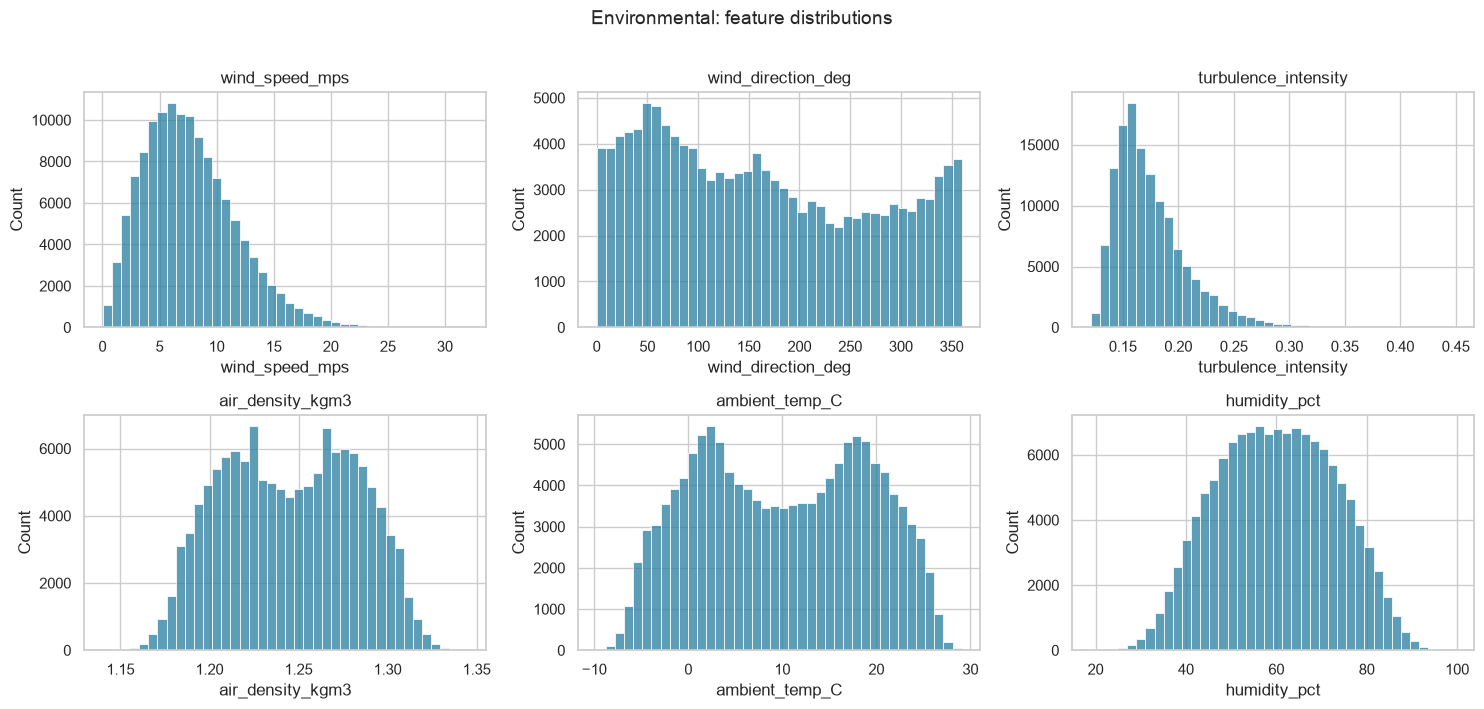

Drivetrain temperatures summary


,count,mean,std,min,25%,50%,75%,max,skew,strong_skew_abs_ge_1,zero_pct
gearbox_oil_temp_C,"131,115.000",58.205,11.836,35.814,49.427,54.307,65.364,109.988,0.851,False,0.000
gearbox_bearing_temp_C,"131,760.000",62.714,13.312,37.901,52.784,58.135,70.859,113.862,0.843,False,0.000
generator_bearing_temp_C,"131,070.000",62.394,11.634,41.375,53.800,58.406,69.132,111.263,0.877,False,0.000
generator_winding_temp_C,"131,760.000",78.593,25.954,44.771,59.489,66.189,92.931,158.996,1.011,True,0.000
main_bearing_temp_C,"131,760.000",52.410,10.961,30.311,44.278,49.042,58.850,94.146,0.820,False,0.000
nacelle_temp_C,"131,760.000",19.792,9.254,-2.681,11.982,19.825,27.515,44.331,0.003,False,0.000


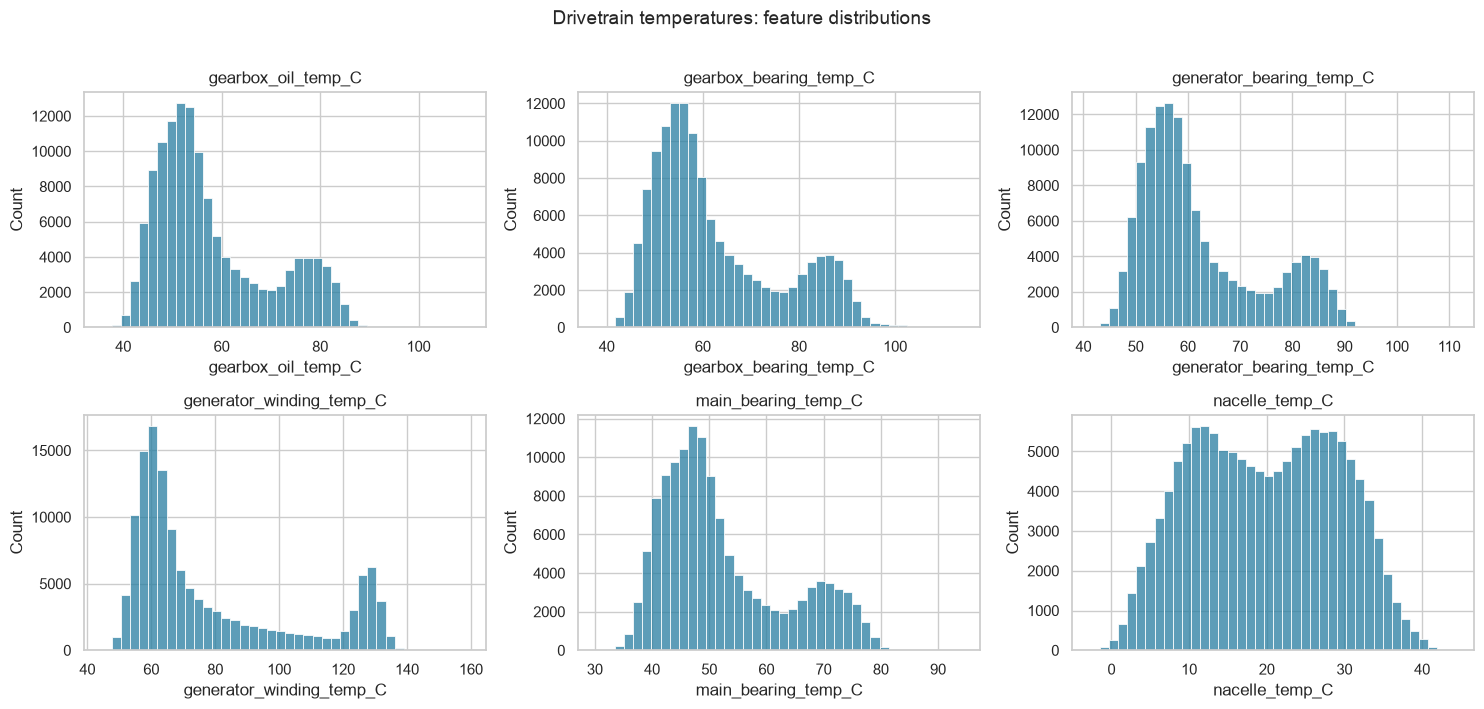

Vibration and FFT summary


,count,mean,std,min,25%,50%,75%,max,skew,strong_skew_abs_ge_1,zero_pct
drivetrain_vibration_rms_mmps,"131,760.000",1.835,0.515,1.216,1.506,1.692,1.976,5.770,2.280,True,0.000
tower_vibration_mmps,"131,760.000",1.135,0.243,0.801,0.957,1.079,1.265,3.717,1.821,True,0.000
vib_fft_bearing_bpfo,"131,760.000",0.435,0.236,0.301,0.349,0.388,0.441,2.577,6.310,True,0.000
vib_fft_bearing_bpfi,"131,760.000",0.422,0.199,0.301,0.349,0.384,0.438,2.846,8.002,True,0.000
vib_fft_gearmesh,"131,760.000",0.585,0.206,0.403,0.479,0.542,0.636,2.837,5.554,True,0.000
vib_fft_sideband,"131,760.000",0.296,0.128,0.203,0.239,0.268,0.313,1.688,6.011,True,0.000


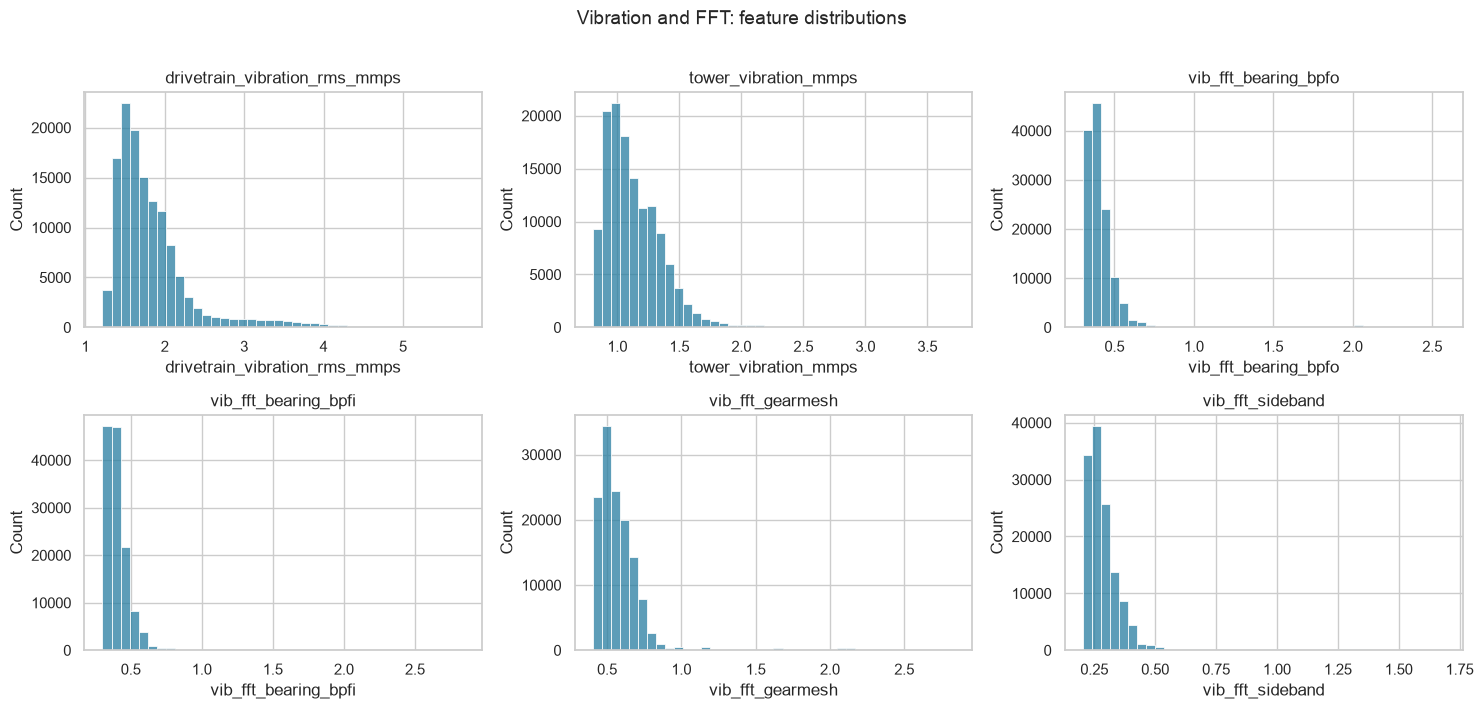

Oil condition summary


,count,mean,std,min,25%,50%,75%,max,skew,strong_skew_abs_ge_1,zero_pct
oil_particle_count,"131,760.000",73.727,31.392,50.565,58.554,64.653,74.938,305.105,3.597,True,0.000
oil_pressure_bar,"131,124.000",5.888,0.239,3.836,5.776,5.915,6.039,6.689,-1.768,True,0.000


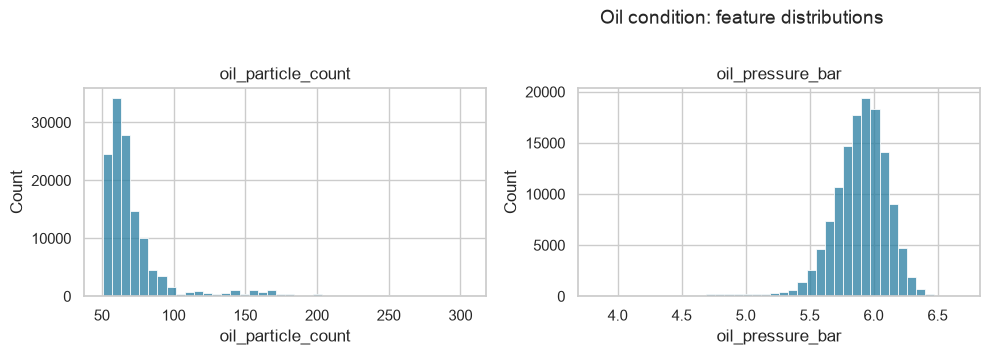

Power and operational summary


,count,mean,std,min,25%,50%,75%,max,skew,strong_skew_abs_ge_1,zero_pct
power_output_kW,"131,760.000",633.608,869.596,0.000,17.358,198.519,"1,014.109","3,672.000",1.641,True,18.361
rotor_speed_rpm,"131,760.000",9.982,4.856,0.000,7.307,10.197,13.596,17.628,-0.514,False,5.617
generator_speed_rpm,"131,760.000",898.630,436.640,0.000,657.570,917.741,"1,223.733","1,590.833",-0.511,False,3.844
blade_pitch_angle_deg,"131,760.000",11.963,27.743,-2.000,0.237,0.750,1.776,90.000,2.296,True,0.030
yaw_misalignment_deg,"131,760.000",0.025,3.414,-25.764,-2.052,0.015,2.089,25.294,0.034,False,0.012


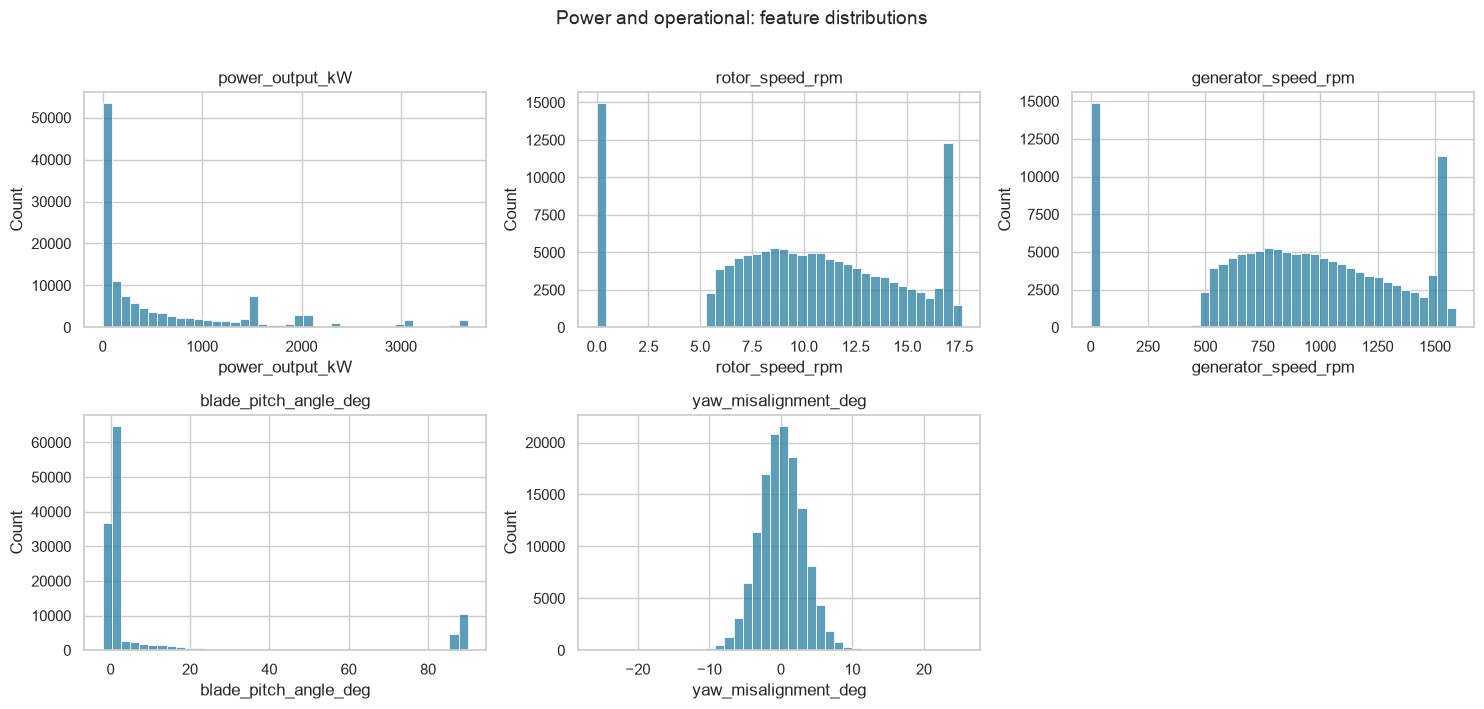

In [4]:
family_summaries = {}
for family_name, columns in sensor_families.items():
    print(f"{family_name} summary")
    family_summaries[family_name] = distribution_summary(columns)
    display(family_summaries[family_name])
    plot_family(family_name, columns)

In [5]:
vibration_columns = sensor_families["Vibration and FFT"]
vibration_variance = pd.DataFrame({
    "variance": df[vibration_columns].var(),
    "coefficient_of_variation": df[vibration_columns].std() / df[vibration_columns].mean().abs(),
    "unique_values": df[vibration_columns].nunique(),
    "modal_share_pct": [df[c].value_counts(normalize=True).iloc[0] * 100 for c in vibration_columns],
})
vibration_variance["near_constant_modal_share_ge_95pct"] = vibration_variance["modal_share_pct"] >= 95
display(vibration_variance)

below_cutin = df["wind_speed_mps"] < 3
below_cutin_mass = pd.DataFrame({
    "measure": ["power_output_kW", "rotor_speed_rpm", "generator_speed_rpm"],
    "rows_below_3_mps": int(below_cutin.sum()),
    "exact_zero_count": [int(df.loc[below_cutin, c].eq(0).sum()) for c in ["power_output_kW", "rotor_speed_rpm", "generator_speed_rpm"]],
    "exact_zero_pct_below_3_mps": [df.loc[below_cutin, c].eq(0).mean() * 100 for c in ["power_output_kW", "rotor_speed_rpm", "generator_speed_rpm"]],
})
display(below_cutin_mass)

,variance,coefficient_of_variation,unique_values,modal_share_pct,near_constant_modal_share_ge_95pct
drivetrain_vibration_rms_mmps,0.266,0.281,3291,0.178,False
tower_vibration_mmps,0.059,0.214,1832,0.257,False
vib_fft_bearing_bpfo,0.055,0.542,280,1.311,False
vib_fft_bearing_bpfi,0.039,0.471,271,1.421,False
vib_fft_gearmesh,0.043,0.353,356,0.984,False
vib_fft_sideband,0.016,0.430,234,1.421,False


,measure,rows_below_3_mps,exact_zero_count,exact_zero_pct_below_3_mps
0,power_output_kW,14875,14875,100.000
1,rotor_speed_rpm,14875,7341,49.351
2,generator_speed_rpm,14875,5030,33.815


## 3. Bivariate Analysis — Target and Feature Relationships

,records,failure_count,failure_rate_pct
turbine_id,,,
T001,8784,558,6.352
T002,8784,169,1.924
T003,8784,166,1.890
T004,8784,355,4.041
T005,8784,240,2.732
T006,8784,281,3.199
T007,8784,492,5.601
T008,8784,478,5.442
T009,8784,100,1.138


,records,failure_count,failure_rate_pct
wind_speed_bin,,,
below cut-in (<3),14875,472,3.173
low (3–<6),36166,1195,3.304
moderate (6–<12),61917,1865,3.012
high (12–<25),18690,419,2.242
extreme (≥25),112,2,1.786


,records,failure_count,failure_rate_pct
rated_power_kW,,,
1500,52704,2037,3.865
2000,35136,710,2.021
2300,8784,337,3.837
3000,17568,585,3.330
3600,17568,284,1.617


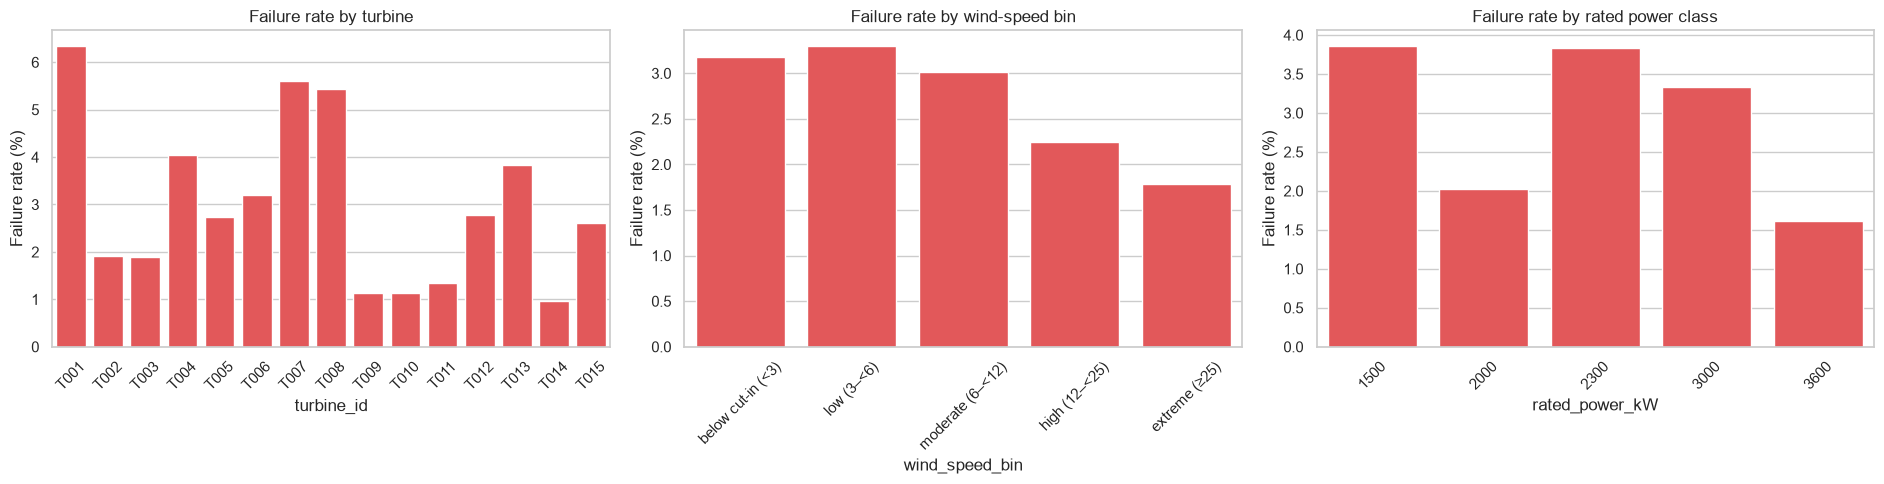

In [6]:
def failure_rate_table(group_column):
    return (df.groupby(group_column, observed=False)["failure"]
              .agg(records="size", failure_count="sum", failure_rate="mean")
              .assign(failure_rate_pct=lambda x: x["failure_rate"] * 100)
              .drop(columns="failure_rate"))

rate_tables = {
    "Turbine": failure_rate_table("turbine_id"),
    "Wind-speed bin": failure_rate_table("wind_speed_bin"),
    "Rated power class": failure_rate_table("rated_power_kW"),
}
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for axis, (title, table) in zip(axes, rate_tables.items()):
    display(table)
    sns.barplot(x=table.index.astype(str), y=table["failure_rate_pct"], ax=axis, color="#f94144")
    axis.set_title(f"Failure rate by {title.lower()}")
    axis.set_ylabel("Failure rate (%)")
    axis.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

gearbox_bearing_temp_C                       \
                         count   mean median    std   
failure                                               
0                       127807 62.480 57.935 13.214   
1                         3953 70.249 69.072 14.242   

        drivetrain_vibration_rms_mmps                    vib_fft_bearing_bpfo  \
                                count  mean median   std                count   
failure                                                                         
0                              127807 1.786  1.681 0.413               127807   
1                                3953 3.407  3.635 0.884                 3953   

                           oil_particle_count                         
         mean median   std              count    mean  median    std  
failure                                                               
0       0.422  0.387 0.176             127807  71.118  64.450 25.315  
1       0.859  0.431 0.814               3953 158.083 165.209 69.222

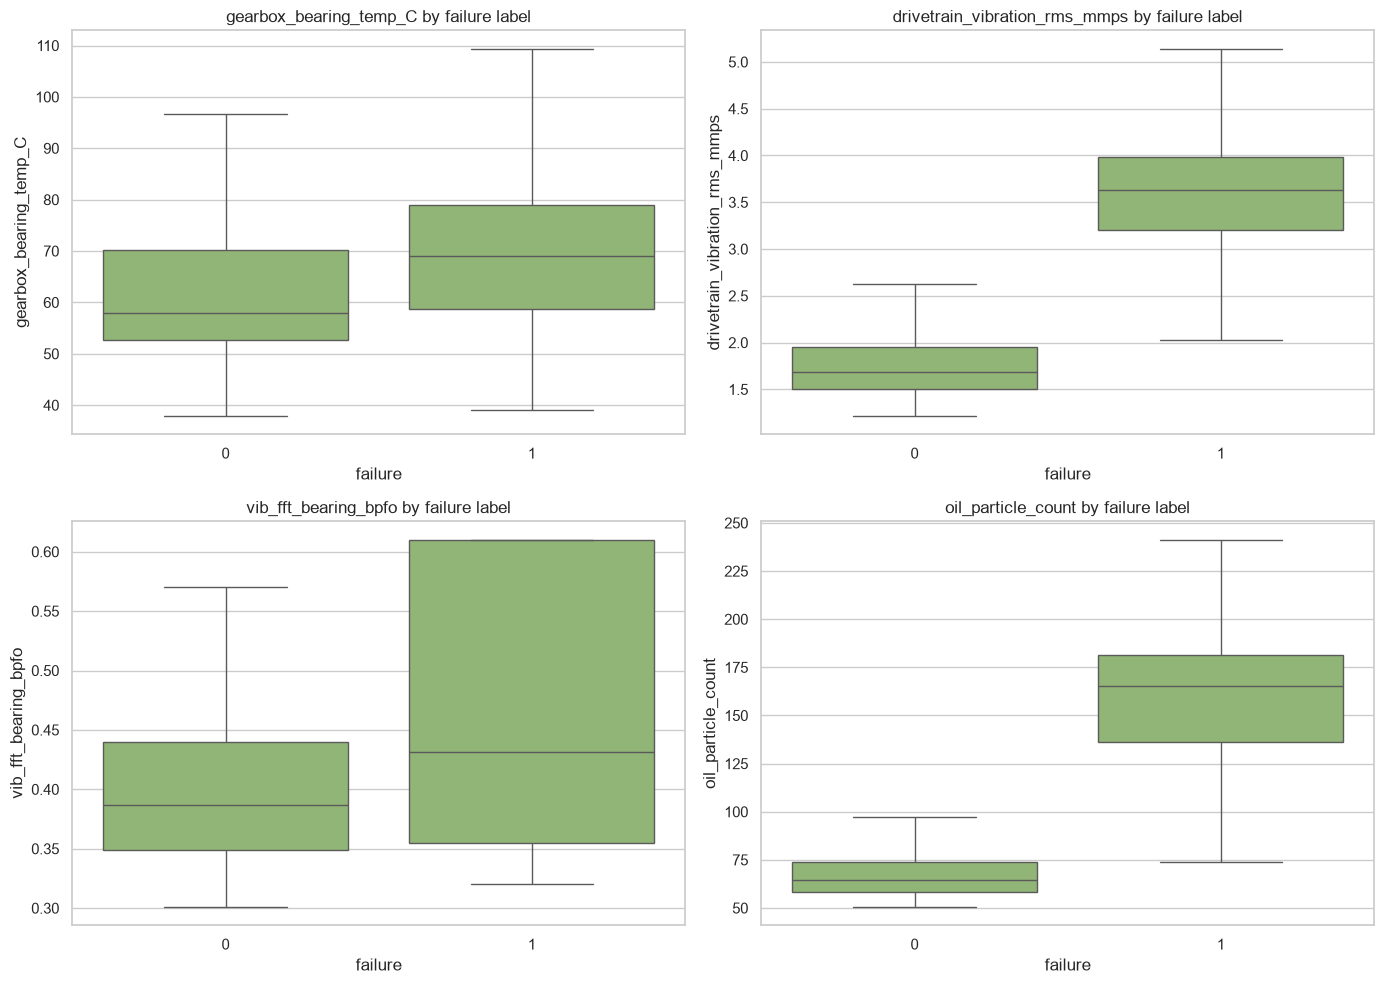

In [7]:
target_comparison_features = [
    "gearbox_bearing_temp_C", "drivetrain_vibration_rms_mmps",
    "vib_fft_bearing_bpfo", "oil_particle_count",
]
target_feature_summary = (df.groupby("failure")[target_comparison_features]
                          .agg(["count", "mean", "median", "std"]))
display(target_feature_summary)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, column in zip(axes.ravel(), target_comparison_features):
    sns.boxplot(data=df, x="failure", y=column, showfliers=False, ax=axis, color="#90be6d")
    axis.set_title(f"{column} by failure label")
fig.tight_layout()
plt.show()

### IQR outliers and failure concentration

Outliers are recomputed per numeric source predictor using `Q1 − 1.5 × IQR` and `Q3 + 1.5 × IQR`. `Failure share among outliers` is compared with the notebook's calculated overall failure rate; no rows are removed.

In [8]:
excluded = ["failure", "hour"]
numeric_source_predictors = df.drop(columns=["timestamp", "turbine_id", "day_of_week", "wind_speed_bin"] + excluded).select_dtypes(include="number").columns
base_failure_rate = (df["failure"] == 1).mean()
outlier_target_rows = []
for column in numeric_source_predictors:
    valid = df[column].notna()
    q1, q3 = df.loc[valid, column].quantile([0.25, 0.75])
    iqr = q3 - q1
    flag = valid & ((df[column] < q1 - 1.5 * iqr) | (df[column] > q3 + 1.5 * iqr))
    outlier_count = int(flag.sum())
    failure_share = df.loc[flag, "failure"].mean() if outlier_count else np.nan
    outlier_target_rows.append({
        "feature": column, "outlier_count": outlier_count,
        "failure_outlier_count": int(df.loc[flag, "failure"].sum()),
        "failure_share_among_outliers_pct": failure_share * 100,
        "overall_failure_rate_pct": base_failure_rate * 100,
        "failure_rate_enrichment_ratio": failure_share / base_failure_rate if outlier_count else np.nan,
    })
outlier_target = pd.DataFrame(outlier_target_rows).sort_values("failure_rate_enrichment_ratio", ascending=False)
display(outlier_target)

,feature,outlier_count,failure_outlier_count,failure_share_among_outliers_pct,overall_failure_rate_pct,failure_rate_enrichment_ratio
15,generator_winding_temp_C,98,60,61.224,3.000,20.407
13,gearbox_bearing_temp_C,457,210,45.952,3.000,15.317
16,main_bearing_temp_C,229,85,37.118,3.000,12.372
14,generator_bearing_temp_C,245,90,36.735,3.000,12.244
18,drivetrain_vibration_rms_mmps,8981,3266,36.366,3.000,12.121
12,gearbox_oil_temp_C,429,149,34.732,3.000,11.577
11,yaw_misalignment_deg,2556,690,26.995,3.000,8.998
24,oil_particle_count,11232,2972,26.460,3.000,8.820
19,tower_vibration_mmps,2980,717,24.060,3.000,8.020
25,oil_pressure_bar,3430,823,23.994,3.000,7.998


## 4. Multivariate Analysis

Counts per turbine × wind-speed bin (review sparse cells before interpreting rates):


wind_speed_bin,below cut-in (<3),low (3–<6),moderate (6–<12),high (12–<25),extreme (≥25)
turbine_id,,,,,
T001,877,2187,4196,1514,10
T002,963,2553,4281,987,0
T003,942,2108,3953,1752,29
T004,1156,2446,3887,1286,9
T005,1138,2299,3728,1593,26
T006,816,2301,4514,1153,0
T007,691,2177,4498,1415,3
T008,1414,2916,3667,786,1
T009,1102,2305,4000,1368,9


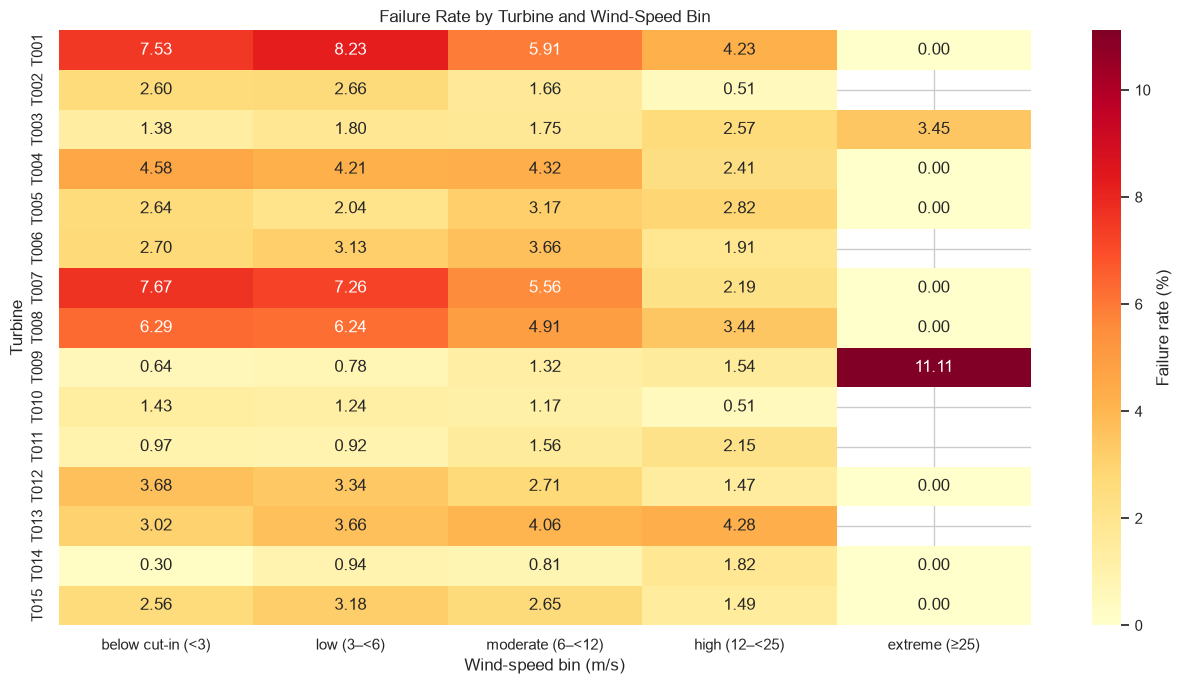

In [9]:
turbine_wind_rate = pd.pivot_table(df, values="failure", index="turbine_id", columns="wind_speed_bin", aggfunc="mean", observed=False) * 100
turbine_wind_count = pd.crosstab(df["turbine_id"], df["wind_speed_bin"], dropna=False)
print("Counts per turbine × wind-speed bin (review sparse cells before interpreting rates):")
display(turbine_wind_count)
plt.figure(figsize=(13, 7))
sns.heatmap(turbine_wind_rate, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "Failure rate (%)"})
plt.title("Failure Rate by Turbine and Wind-Speed Bin")
plt.xlabel("Wind-speed bin (m/s)")
plt.ylabel("Turbine")
plt.tight_layout()
plt.show()

Counts per day-of-week × hour (review sparse cells before interpreting rates):


hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,,,,
Monday,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810
Tuesday,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810
Wednesday,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810
Thursday,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810
Friday,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810,810
Saturday,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720
Sunday,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720,720


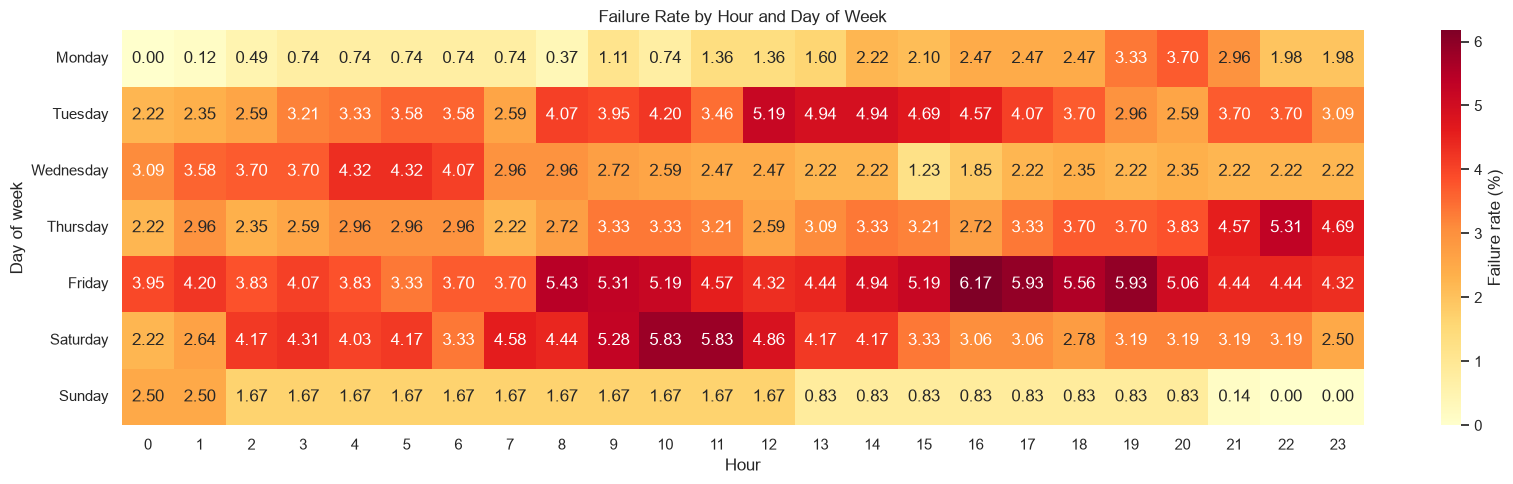

In [10]:
hour_day_rate = pd.pivot_table(df, values="failure", index="day_of_week", columns="hour", aggfunc="mean", observed=False) * 100
hour_day_count = pd.crosstab(df["day_of_week"], df["hour"], dropna=False)
print("Counts per day-of-week × hour (review sparse cells before interpreting rates):")
display(hour_day_count)
plt.figure(figsize=(17, 5))
sns.heatmap(hour_day_rate, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "Failure rate (%)"})
plt.title("Failure Rate by Hour and Day of Week")
plt.xlabel("Hour")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()

Ten strongest absolute Pearson correlation pairs:


,feature_1,feature_2,correlation,absolute_correlation
165,rotor_speed_rpm,generator_speed_rpm,1.000,1.000
0,gearbox_oil_temp_C,gearbox_bearing_temp_C,0.960,0.960
35,generator_bearing_temp_C,generator_winding_temp_C,0.958,0.958
36,generator_bearing_temp_C,main_bearing_temp_C,0.952,0.952
51,generator_winding_temp_C,main_bearing_temp_C,0.943,0.943
3,gearbox_oil_temp_C,main_bearing_temp_C,0.941,0.941
1,gearbox_oil_temp_C,generator_bearing_temp_C,0.938,0.938
19,gearbox_bearing_temp_C,generator_winding_temp_C,0.937,0.937
2,gearbox_oil_temp_C,generator_winding_temp_C,0.937,0.937
20,gearbox_bearing_temp_C,main_bearing_temp_C,0.935,0.935


Strongest pair: rotor_speed_rpm and generator_speed_rpm (r=0.999840).
Pairs with absolute correlation >= 0.90: 12
These pairs are flagged for later multicollinearity review; no feature selection is performed here.


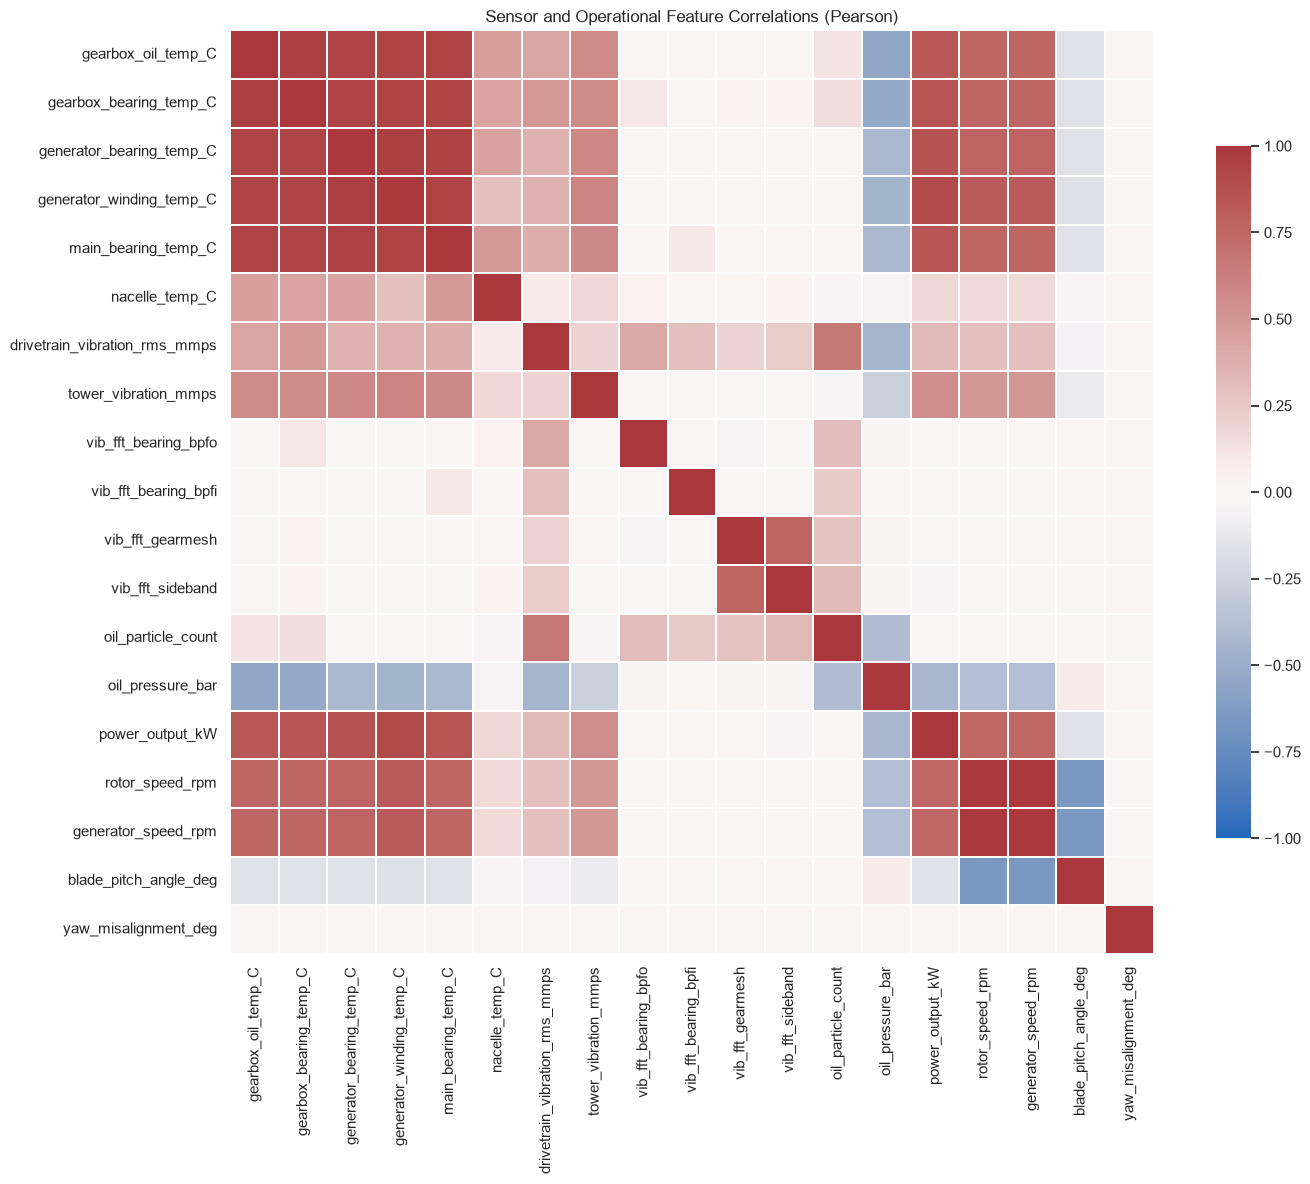

In [11]:
correlation_features = (sensor_families["Drivetrain temperatures"] + sensor_families["Vibration and FFT"] +
                        sensor_families["Oil condition"] + sensor_families["Power and operational"])
correlation_matrix = df[correlation_features].corr(method="pearson")
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
strongest_pairs = (upper_triangle.stack().rename("correlation").reset_index()
                   .rename(columns={"level_0": "feature_1", "level_1": "feature_2"}))
strongest_pairs["absolute_correlation"] = strongest_pairs["correlation"].abs()
all_ranked_pairs = strongest_pairs.sort_values("absolute_correlation", ascending=False)
strongest_pairs = all_ranked_pairs.head(10)
print("Ten strongest absolute Pearson correlation pairs:")
display(strongest_pairs)
top_pair = strongest_pairs.iloc[0]
print(f"Strongest pair: {top_pair['feature_1']} and {top_pair['feature_2']} (r={top_pair['correlation']:.6f}).")
print(f"Pairs with absolute correlation >= 0.90: {(all_ranked_pairs['absolute_correlation'] >= 0.90).sum():,}")
print("These pairs are flagged for later multicollinearity review; no feature selection is performed here.")
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.25, cbar_kws={"shrink": 0.75})
plt.title("Sensor and Operational Feature Correlations (Pearson)")
plt.tight_layout()
plt.show()

### Representative episode-level trends

A failure episode is a per-turbine run of `failure=1` rows at 10-minute cadence. The six longest multi-row episodes are selected deterministically. Each plot includes the preceding 12 rows (two hours) when available and the full episode. The comparison table reports early pre-onset mean (−120 to −70 minutes), late pre-onset mean (−60 to −10), onset value, percentage change across the pre-window, and percentage jump from late pre-window to onset.

In [12]:
ten_minutes = np.timedelta64(10, "m")
episode_rows = []
for turbine_id, turbine in df.sort_values(["turbine_id", "timestamp"]).groupby("turbine_id"):
    faults = turbine.loc[turbine["failure"] == 1, ["timestamp"]]
    new_episode = faults["timestamp"].diff().ne(ten_minutes)
    for episode_number, episode in faults.groupby(new_episode.cumsum()):
        episode_rows.append({
            "turbine_id": turbine_id, "episode_number": int(episode_number),
            "start": episode["timestamp"].min(), "end": episode["timestamp"].max(),
            "failure_rows": len(episode),
        })
episodes = pd.DataFrame(episode_rows)
print(f"Failure episodes reconstructed: {len(episodes):,}")
print(f"Multi-row episodes: {(episodes['failure_rows'] > 1).sum():,}")
representative_episodes = (episodes.loc[episodes["failure_rows"] > 1]
                           .sort_values(["failure_rows", "turbine_id", "start"], ascending=[False, True, True])
                           .head(6).reset_index(drop=True))
representative_episodes["episode_label"] = representative_episodes.apply(
    lambda row: f"{row['turbine_id']} | {row['start']} | {row['failure_rows']} rows", axis=1)
display(representative_episodes)

Failure episodes reconstructed: 219
Multi-row episodes: 150


,turbine_id,episode_number,start,end,failure_rows,episode_label
0,T007,7,2024-02-17 07:20:00,2024-02-18 21:00:00,227,T007 | 2024-02-17 07:20:00 | 227 rows
1,T001,14,2024-02-23 13:50:00,2024-02-25 01:50:00,217,T001 | 2024-02-23 13:50:00 | 217 rows
2,T007,17,2024-02-29 13:30:00,2024-03-01 20:00:00,184,T007 | 2024-02-29 13:30:00 | 184 rows
3,T008,15,2024-02-07 17:00:00,2024-02-08 23:20:00,183,T008 | 2024-02-07 17:00:00 | 183 rows
4,T013,10,2024-01-25 14:50:00,2024-01-26 20:50:00,181,T013 | 2024-01-25 14:50:00 | 181 rows
5,T015,8,2024-02-22 16:40:00,2024-02-23 18:20:00,155,T015 | 2024-02-22 16:40:00 | 155 rows


,episode_label,feature,early_pre_mean,late_pre_mean,onset_value,pre_window_change_pct,onset_jump_from_late_pre_pct
0,T007 | 2024-02-17 07:20:00 | 227 rows,gearbox_bearing_temp_C,88.740,83.659,72.866,-5.726,-12.901
1,T007 | 2024-02-17 07:20:00 | 227 rows,drivetrain_vibration_rms_mmps,3.744,3.478,3.440,-7.083,-1.102
2,T001 | 2024-02-23 13:50:00 | 217 rows,gearbox_bearing_temp_C,74.296,64.124,53.247,-13.690,-16.963
3,T001 | 2024-02-23 13:50:00 | 217 rows,drivetrain_vibration_rms_mmps,1.799,1.650,1.675,-8.255,1.495
4,T007 | 2024-02-29 13:30:00 | 184 rows,gearbox_bearing_temp_C,70.974,77.332,73.188,8.958,-5.358
5,T007 | 2024-02-29 13:30:00 | 184 rows,drivetrain_vibration_rms_mmps,3.708,3.676,3.557,-0.859,-3.233
6,T008 | 2024-02-07 17:00:00 | 183 rows,gearbox_bearing_temp_C,52.282,57.376,50.264,9.742,-12.395
7,T008 | 2024-02-07 17:00:00 | 183 rows,drivetrain_vibration_rms_mmps,3.336,3.687,3.774,10.512,2.369
8,T013 | 2024-01-25 14:50:00 | 181 rows,gearbox_bearing_temp_C,52.210,53.100,50.388,1.705,-5.106
9,T013 | 2024-01-25 14:50:00 | 181 rows,drivetrain_vibration_rms_mmps,3.648,3.629,3.626,-0.530,-0.073


Median trend metrics across the six representative episodes:


,pre_window_change_pct,onset_jump_from_late_pre_pct
feature,,
drivetrain_vibration_rms_mmps,-0.694,0.711
gearbox_bearing_temp_C,3.651,-8.877


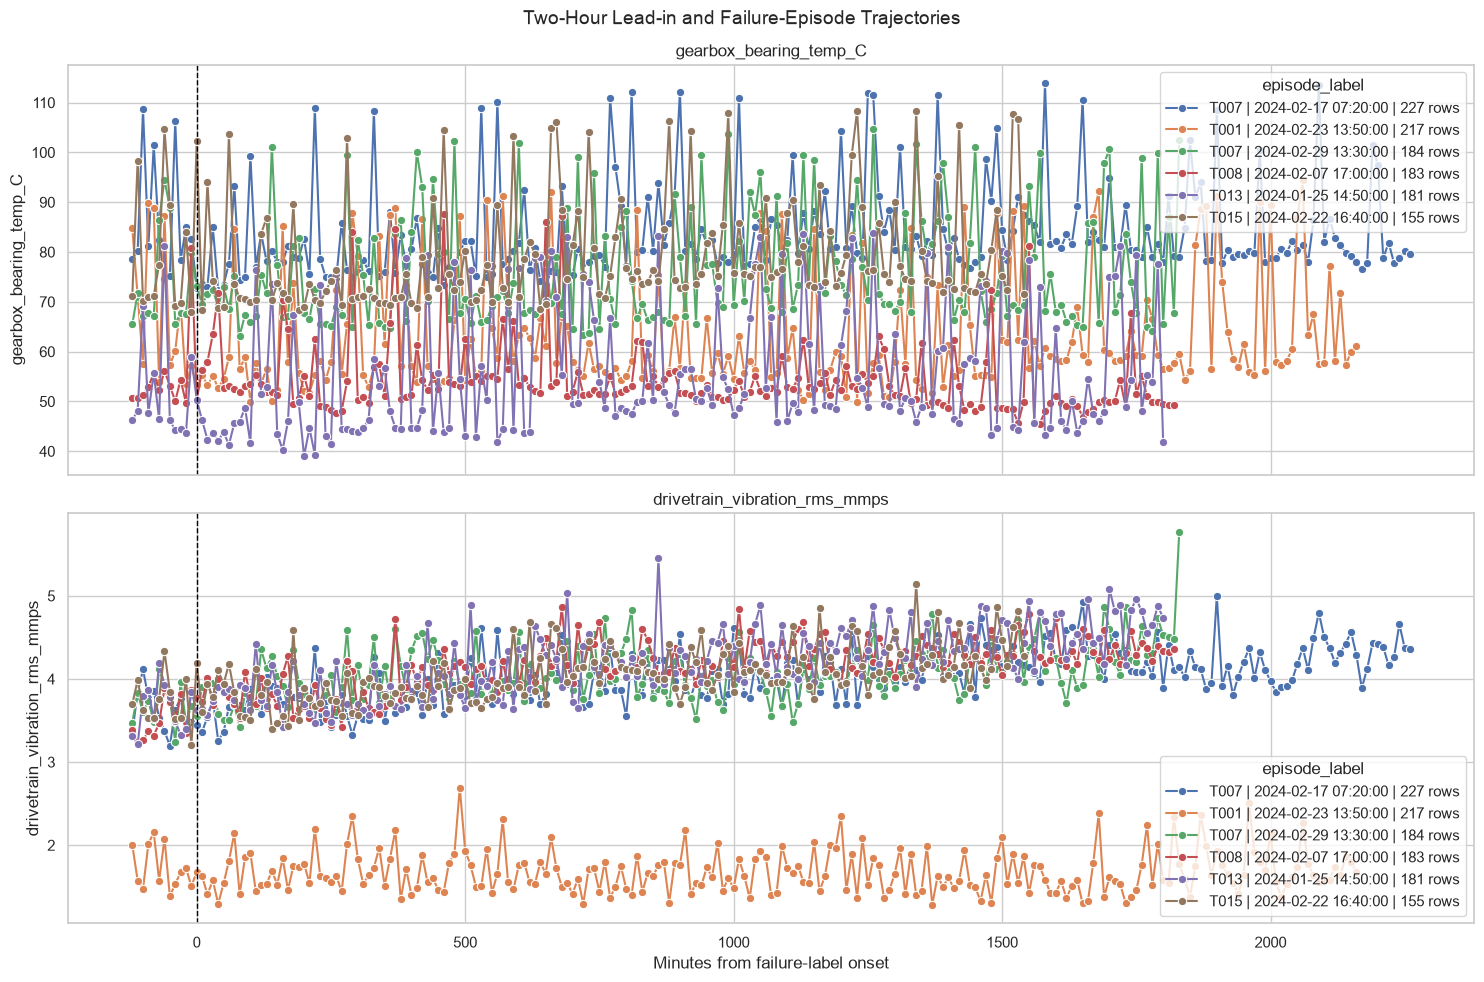

In [13]:
trend_features = ["gearbox_bearing_temp_C", "drivetrain_vibration_rms_mmps"]
contexts = []
trend_metrics = []
for episode in representative_episodes.itertuples(index=False):
    turbine = df.loc[df["turbine_id"] == episode.turbine_id].sort_values("timestamp")
    context = turbine.loc[turbine["timestamp"].between(episode.start - pd.offsets.Hour(2), episode.end),
                          ["timestamp", *trend_features]].copy()
    context["minutes_from_onset"] = (context["timestamp"] - episode.start).dt.total_seconds() / 60
    context["episode_label"] = episode.episode_label
    contexts.append(context)
    for feature in trend_features:
        early = context.loc[context["minutes_from_onset"].between(-120, -70), feature].dropna()
        late = context.loc[context["minutes_from_onset"].between(-60, -10), feature].dropna()
        onset = context.loc[context["minutes_from_onset"] == 0, feature].dropna()
        early_mean, late_mean = early.mean(), late.mean()
        onset_value = onset.iloc[0] if len(onset) else np.nan
        trend_metrics.append({
            "episode_label": episode.episode_label, "feature": feature,
            "early_pre_mean": early_mean, "late_pre_mean": late_mean, "onset_value": onset_value,
            "pre_window_change_pct": (late_mean - early_mean) / abs(early_mean) * 100,
            "onset_jump_from_late_pre_pct": (onset_value - late_mean) / abs(late_mean) * 100,
        })
episode_context = pd.concat(contexts, ignore_index=True)
trend_metrics = pd.DataFrame(trend_metrics)
display(trend_metrics)
print("Median trend metrics across the six representative episodes:")
display(trend_metrics.groupby("feature")[["pre_window_change_pct", "onset_jump_from_late_pre_pct"]].median())

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
for axis, feature in zip(axes, trend_features):
    sns.lineplot(data=episode_context, x="minutes_from_onset", y=feature, hue="episode_label", marker="o", ax=axis)
    axis.axvline(0, color="black", linestyle="--", linewidth=1, label="failure onset")
    axis.set_title(feature)
    axis.set_ylabel(feature)
axes[-1].set_xlabel("Minutes from failure-label onset")
fig.suptitle("Two-Hour Lead-in and Failure-Episode Trajectories", fontsize=14)
fig.tight_layout()
plt.show()

## 5. Diagnostic Stratified Random Split

The output of this section is discarded: it is not saved or reused, and the authoritative split lives in notebook 03. This split is included only to verify a conventional 70%/15%/15% target-stratified partition with a fixed seed. It is **not approved for final modeling** because random SCADA rows from the same turbine, adjacent timestamps, and possibly the same fault episode can cross partitions. Notebook 03's grouped and temporal split remains the authoritative modeling design.

In [14]:
RANDOM_SEED = 42
X_diagnostic = df.drop(columns="failure")
y_diagnostic = df["failure"]

X_train_diag, X_holdout_diag, y_train_diag, y_holdout_diag = train_test_split(
    X_diagnostic, y_diagnostic, test_size=0.30, random_state=RANDOM_SEED, stratify=y_diagnostic,
)
X_validation_diag, X_test_diag, y_validation_diag, y_test_diag = train_test_split(
    X_holdout_diag, y_holdout_diag, test_size=0.50, random_state=RANDOM_SEED, stratify=y_holdout_diag,
)
diagnostic_splits = {
    "train": (X_train_diag, y_train_diag),
    "validation": (X_validation_diag, y_validation_diag),
    "test": (X_test_diag, y_test_diag),
}
diagnostic_split_report = pd.DataFrame([
    {
        "split": name, "X_shape": features.shape, "y_shape": target.shape,
        "rows": len(target), "row_pct": len(target) / len(df) * 100,
        "failure_count": int(target.sum()), "failure_rate_pct": target.mean() * 100,
    }
    for name, (features, target) in diagnostic_splits.items()
]).set_index("split")
print(f"Fixed random seed: {RANDOM_SEED}")
display(diagnostic_split_report)

Fixed random seed: 42


,X_shape,y_shape,rows,row_pct,failure_count,failure_rate_pct
split,,,,,,
train,"(92232, 37)","(92232,)",92232,70.000,2767,3.000
validation,"(19764, 37)","(19764,)",19764,15.000,593,3.000
test,"(19764, 37)","(19764,)",19764,15.000,593,3.000


## Key Findings Recap

- Strong skew (`|skew| >= 1`) appears in turbulence intensity (1.503), generator winding temperature (1.011), every vibration/FFT feature (1.821 to 8.002), oil particle count (3.597), oil pressure (−1.768), power output (1.641), and blade pitch angle (2.296).
- None of the vibration/FFT features met the 95% modal-share near-constant rule; below 3 m/s, power output was exactly zero in all 14,875 rows, while rotor and generator speeds were exactly zero in 49.351% and 33.815% of those rows.
- Failure rates varied from 0.968% for `T014` to 6.352% for `T001`; by wind bin they were highest in the 3–<6 m/s range (3.304%), while the extreme-wind estimate was based on only 112 records.
- Five rated-power classes are present; their failure rates ranged from 1.617% at 3,600 kW to 3.865% at 1,500 kW.
- Failure rows had higher means than normal rows for gearbox-bearing temperature (70.249 vs 62.480 °C), drivetrain RMS vibration (3.407 vs 1.786 mm/s), bearing BPFO amplitude (0.859 vs 0.422), and oil particle count (158.083 vs 71.118).
- IQR outliers were concentrated in failure rows for several condition signals: 61.224% of generator-winding-temperature outliers, 45.952% of gearbox-bearing-temperature outliers, 36.366% of drivetrain-vibration outliers, and 26.460% of oil-particle outliers were failures, compared with the 3.000% overall rate.
- Rotor and generator speed formed the strongest correlated pair (`r=0.999840`), and 12 feature pairs had `|r| >= 0.90`, flagging substantial redundancy for later multicollinearity review. (Notebook 03's preprocessing step reports 17 such pairs on the train-only split—the difference reflects full-dataset versus train-subset scope, not a computation discrepancy.)
- Across the six longest multi-row episodes, median pre-window change was 3.651% for gearbox-bearing temperature and −0.694% for drivetrain vibration; median onset jumps were −8.877% and 0.711%, respectively, so these episodes did not show a consistent shared ramp at label onset.